# Task 4 — Results Analysis & Documentation
## Federated Learning for Heart Disease

This notebook loads the training results from the experiments (FedAvg, FedAdam, FedProx, Local SGD) and plots the metrics to analyze:
- **Convergence**: Accuracy and Loss per round, Oscillations
- **Generalization**: Comparison between IID and non-IID data distributions


In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_dir = os.path.join("..", "outputs", "results")
strategies = ["FedAvg", "FedAdam", "FedProx", "LocalSGD"]
modes = ["iid", "noniid"]


In [2]:
results = {}
for mode in modes:
    results[mode] = {}
    for strat in strategies:
        filepath = os.path.join(results_dir, f"{strat}_{mode}.json")
        if os.path.exists(filepath):
            with open(filepath, 'r') as f:
                results[mode][strat] = json.load(f)
        else:
            print(f"Warning: {filepath} not found")


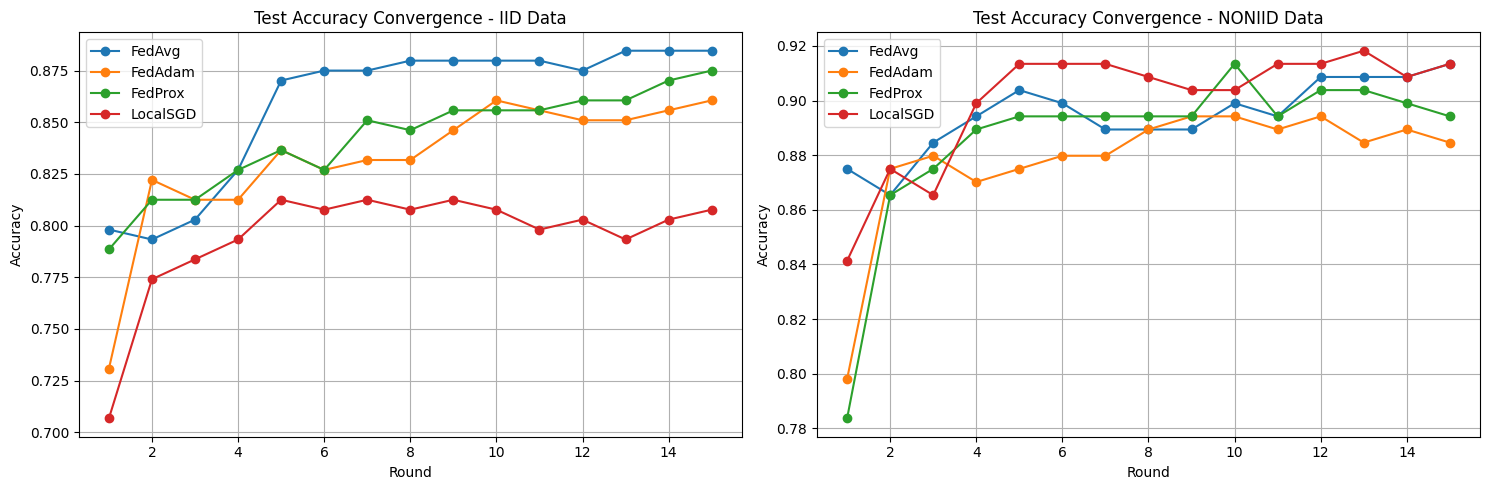

In [3]:
# Convergence: Accuracy per round
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, mode in enumerate(modes):
    ax = axes[i]
    for strat in strategies:
        if strat in results[mode]:
            res = results[mode][strat]
            acc_data = res.get("metrics_distributed", {}).get("accuracy", [])
            if acc_data:
                rounds, accs = zip(*acc_data)
                ax.plot(rounds, accs, marker='o', label=strat)
    ax.set_title(f"Test Accuracy Convergence - {mode.upper()} Data")
    ax.set_xlabel("Round")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "figures", "accuracy_convergence.png"))
plt.show()


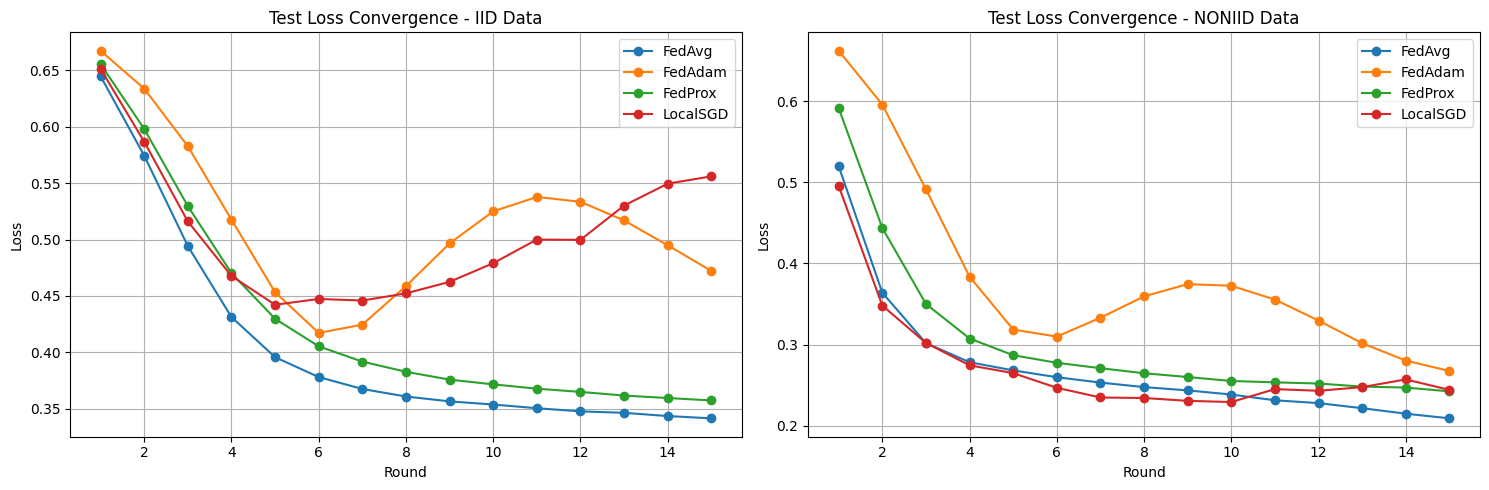

In [4]:
# Convergence: Loss per round
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, mode in enumerate(modes):
    ax = axes[i]
    for strat in strategies:
        if strat in results[mode]:
            res = results[mode][strat]
            loss_data = res.get("losses_distributed", [])
            if loss_data:
                rounds, losses = zip(*loss_data)
                ax.plot(rounds, losses, marker='o', label=strat)
    ax.set_title(f"Test Loss Convergence - {mode.upper()} Data")
    ax.set_xlabel("Round")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "figures", "loss_convergence.png"))
plt.show()


In [5]:
# Final Metrics Table
data = []
for mode in modes:
    for strat in strategies:
        if strat in results[mode]:
            res = results[mode][strat]
            # Get last round metrics
            acc = res.get("metrics_distributed", {}).get("accuracy", [(0, 0)])[-1][1]
            f1 = res.get("metrics_distributed", {}).get("f1", [(0, 0)])[-1][1]
            data.append({"Mode": mode.upper(), "Strategy": strat, "Final Accuracy": acc, "Final F1": f1})

df = pd.DataFrame(data)
display(df)


,Mode,Strategy,Final Accuracy,Final F1
0,IID,FedAvg,0.884615,0.883593
1,IID,FedAdam,0.860577,0.859323
2,IID,FedProx,0.875000,0.877383
3,IID,LocalSGD,0.807692,0.790392
4,NONIID,FedAvg,0.913462,0.863222
5,NONIID,FedAdam,0.884615,0.829829
6,NONIID,FedProx,0.894231,0.842949
7,NONIID,LocalSGD,0.913462,0.803797
